<a href="https://colab.research.google.com/github/oyueo-mm/MNIST_Fashion_generator_by_entry/blob/main/MNIST_%ED%8C%A8%EC%85%98%2C_CVAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 가져오기

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [ ]:
latent_dim = 20
epochs = 50
batch_size = 128
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(root = "./data", download = True, transform = transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.4MB/s]


In [ ]:
image, label = train_dataset[0]

print(image.shape)  # torch.Size([1, 28, 28])
print(label)        # 정수 라벨

torch.Size([1, 28, 28])
9


In [ ]:
classes = [
    "T-shirt/top", "Trouser", "Pullover",
    "Dress", "Coat", "Sandal",
    "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(classes[label])

Ankle boot


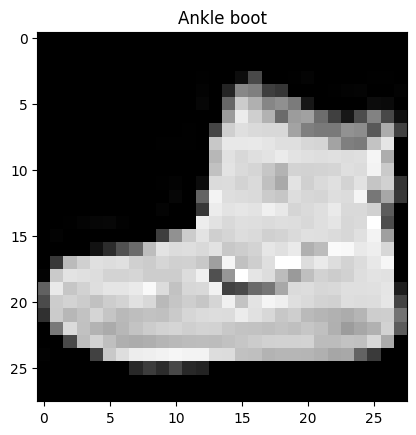

In [ ]:
import matplotlib.pyplot as plt

plt.title(f"{classes[label]}")
plt.imshow(image.reshape(28, 28), cmap = 'gray')
plt.show()

In [ ]:
next(iter(train_loader))

[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

# 학습

In [ ]:
class CVAE(nn.Module):
  def __init__(self, latent_dim = 20, num_classes = 10):
    super(CVAE, self).__init__()
    self.encoder = nn.Sequential(
        nn.Linear(784 + num_classes, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
    )
    self.mu = nn.Linear(256, latent_dim)
    self.logvar = nn.Linear(256, latent_dim)
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim + num_classes, 256),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.ReLU(),
        nn.Linear(512, 784),
        nn.Sigmoid()
    )

  def encode(self, x, c):
    x = x.view(-1, 784)
    combined_input = torch.cat([x, c], dim=1)
    h = self.encoder(combined_input)
    mu = self.mu(h)
    logvar = self.logvar(h)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z, c):
    c_onehot = c
    combined_input = torch.cat([z, c_onehot], dim=1)
    return self.decoder(combined_input)

  def forward(self, x, c):
    mu, logvar = self.encode(x, c)
    z = self.reparameterize(mu, logvar)
    return self.decode(z, c), mu, logvar

def loss_function(recon_x, x, mu, logvar):
  BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return BCE + KLD

In [ ]:
def plot_conditional_generation(model, latent_dim, num_classes=10, num_z=5):
  model.eval()
  fig, axes = plt.subplots(num_z, num_classes, figsize=(1.2 * num_classes, 1.0 * num_z))

  with torch.no_grad():
    for row in range(num_z):
      z_sample = torch.randn(1, latent_dim).to(device)

      for col in range(num_classes):
        target_label = torch.tensor([col]).to(device)
        y_sample = F.one_hot(target_label, num_classes=num_classes).float()

        generated_img = model.decode(z_sample, y_sample)
        generated_img = generated_img.view(28, 28).cpu().numpy()

        axes[row, col].imshow(generated_img, cmap='gray')
        axes[row, col].axis('off')
        axes[row, col].set_aspect('equal')

        if row == 0:
          axes[row, col].set_title(classes[col], fontsize=9, pad=8, rotation=30, ha='center')

  plt.tight_layout()
  plt.show()

1 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

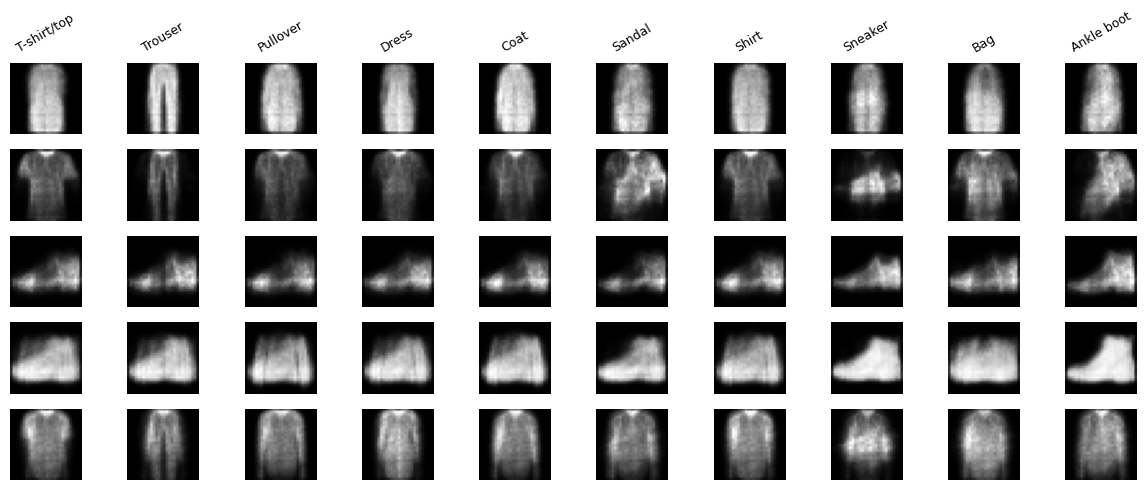

2 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

3 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

4 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

5 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

6 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

7 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

8 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

9 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

10 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

11 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

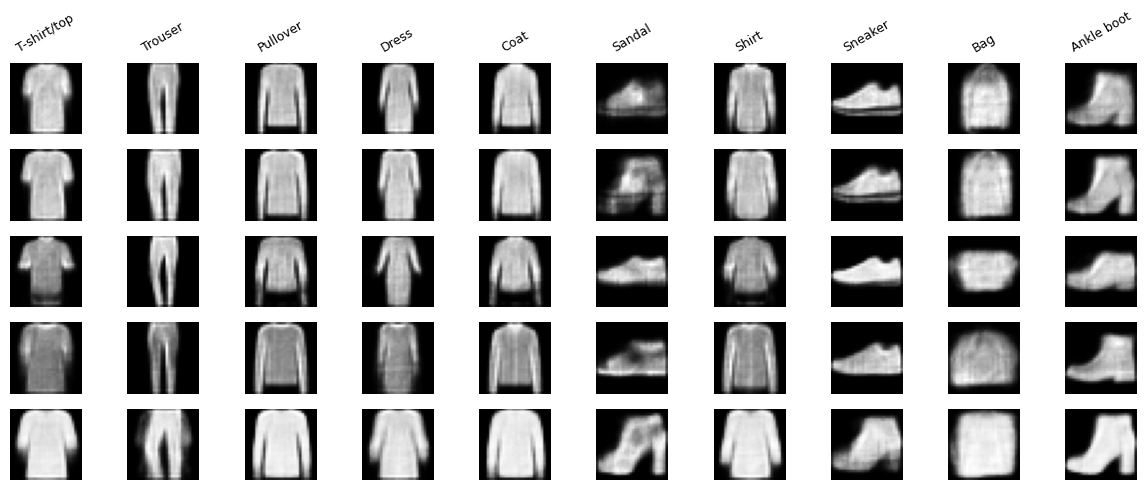

12 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

13 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

14 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

15 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

16 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

17 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

18 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

19 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

20 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

21 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

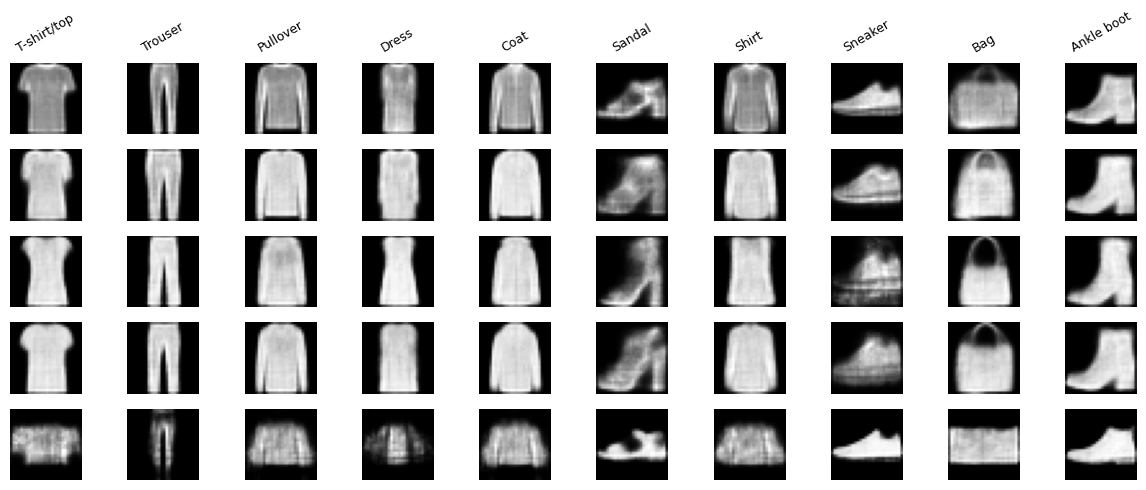

22 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

23 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

24 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

25 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

26 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

27 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

28 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

29 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

30 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

31 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

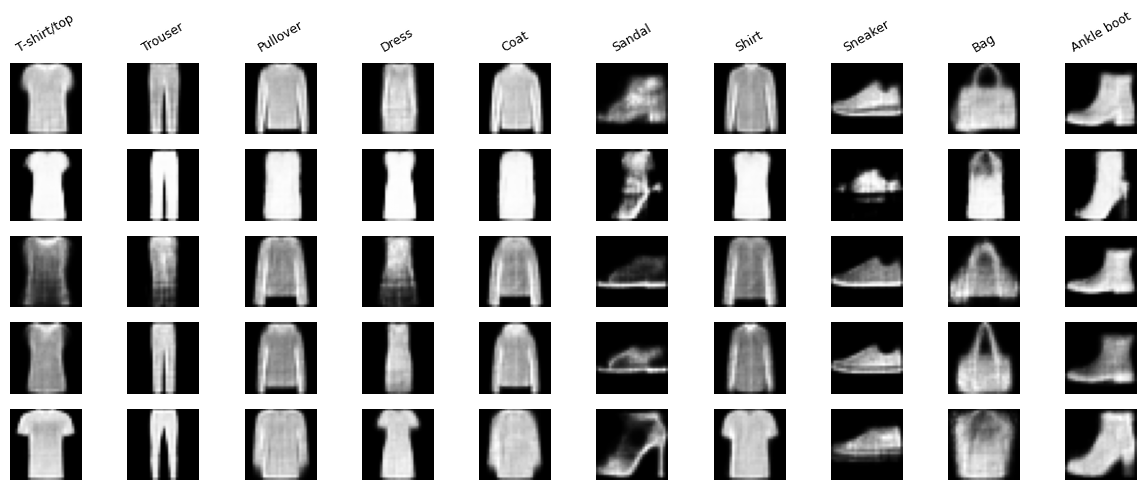

32 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

33 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

34 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

35 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

36 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

37 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

38 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

39 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

40 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

41 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

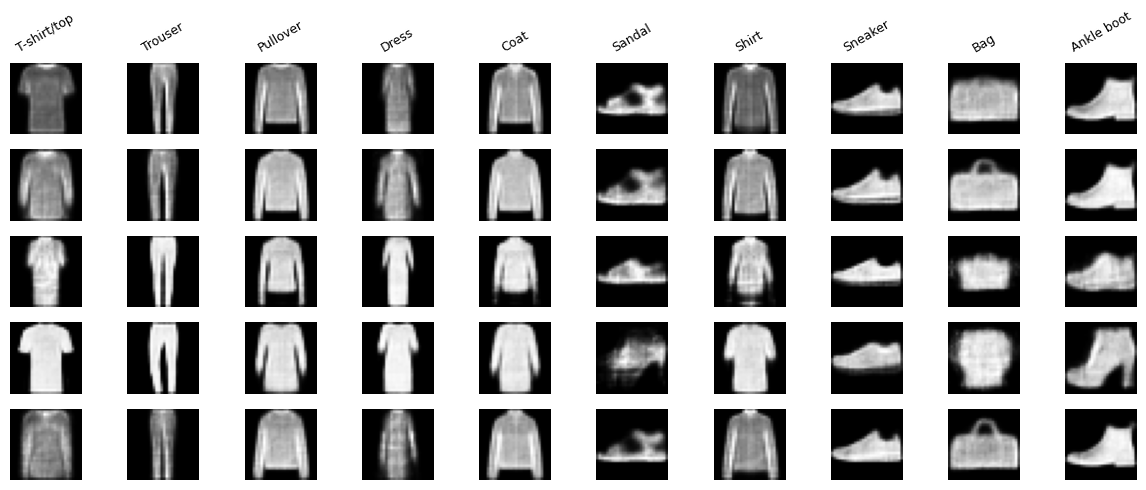

42 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

43 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

44 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

45 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

46 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

47 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

48 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

49 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

50 / 50:   0%|          | 0/469 [00:00<?, ?it/s]

In [ ]:
from tqdm.notebook import tqdm

model = CVAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


for epoch in range(epochs):
  model.train()
  train_loss = 0
  pbar = tqdm(train_loader, desc=f"{epoch+1} / {epochs}")
  for data, labels in pbar:
    data = data.to(device)

    y_one_hot = F.one_hot(labels.long(), num_classes=num_classes).float().to(device)

    optimizer.zero_grad()
    recon_batch, mu, logvar = model(data, y_one_hot)

    loss = loss_function(recon_batch, data, mu, logvar)
    loss.backward()
    train_loss += loss.item()
    optimizer.step()

    pbar.set_postfix(loss=f"{loss.item():.2f}")
  if epoch % 10 == 0:
    plot_conditional_generation(model, latent_dim, num_classes)

# 저장

In [ ]:
torch.save(model.state_dict(), "CVAE.pth")

In [ ]:
latent_dim = 20
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = CVAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('CVAE.pth', map_location=torch.device('cpu')))
model.to(torch.device('cpu'))

cuda


CVAE(
  (encoder): Sequential(
    (0): Linear(in_features=794, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=256, out_features=20, bias=True)
  (logvar): Linear(in_features=256, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:
import torch
import csv
import os

def export_entry_ultimate_clean_csv(pth_path, output_dir='entry_final_csv'):
  state_dict = torch.load(pth_path, map_location='cpu')

  if not os.path.exists(output_dir):
    os.makedirs(output_dir)

  layer_mapping = {
	'decoder.0': 'layer1',
	'decoder.2': 'layer2',
	'decoder.4': 'layer3'
  }

  for pth_name, entry_name in layer_mapping.items():
    weight = state_dict[f'{pth_name}.weight'].numpy()
    bias = state_dict[f'{pth_name}.bias'].numpy()
    num_nodes = len(weight)

    w_rows = []
    for i in range(num_nodes):
      row_str = ""
      for w_idx, w in enumerate(weight[i]):
        row_str += f"<w{w_idx+1}>{round(float(w), 5)}"
      row_str += "<빈공간>"
      w_rows.append([row_str])

    with open(f'{output_dir}/w_{entry_name}.csv', 'w', newline='', encoding='utf-8') as f:
      writer = csv.writer(f)
      writer.writerows(w_rows)

    b_rows = []
    for i in range(num_nodes):
      b_val = round(float(bias[i]), 5)
      b_rows.append([str(b_val)])

    with open(f'{output_dir}/b_{entry_name}.csv', 'w', newline='', encoding='utf-8') as f:
      writer = csv.writer(f)
      writer.writerows(b_rows)

export_entry_ultimate_clean_csv('CVAE.pth')

# 배경뽑기

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [ ]:
latent_dim = 20
epochs = 50
batch_size = 128
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
class CVAE(nn.Module):
  def __init__(self, latent_dim = 20, num_classes = 10):
    super(CVAE, self).__init__()
    self.encoder = nn.Sequential(
        nn.Linear(784 + num_classes, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU(),
    )
    self.mu = nn.Linear(256, latent_dim)
    self.logvar = nn.Linear(256, latent_dim)
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim + num_classes, 256),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.ReLU(),
        nn.Linear(512, 784),
        nn.Sigmoid()
    )

  def encode(self, x, c):
    x = x.view(-1, 784)
    combined_input = torch.cat([x, c], dim=1)
    h = self.encoder(combined_input)
    mu = self.mu(h)
    logvar = self.logvar(h)
    return mu, logvar

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def decode(self, z, c):
    c_onehot = c
    combined_input = torch.cat([z, c_onehot], dim=1)
    return self.decoder(combined_input)

  def forward(self, x, c):
    mu, logvar = self.encode(x, c)
    z = self.reparameterize(mu, logvar)
    return self.decode(z, c), mu, logvar

def loss_function(recon_x, x, mu, logvar):
  BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return BCE + KLD

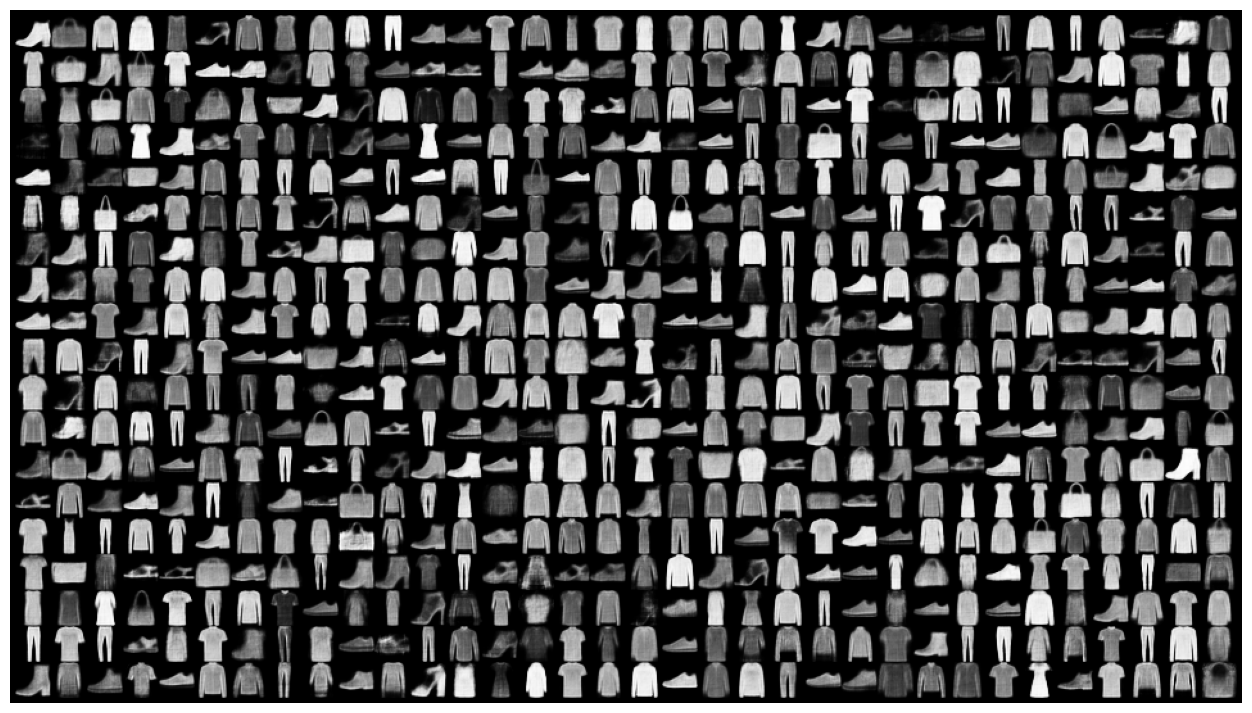

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import random

device = "cuda" if torch.cuda.is_available() else "cpu"

model = CVAE(latent_dim=latent_dim, num_classes=num_classes)
model = model.to(device)
model.load_state_dict(torch.load("CVAE.pth", map_location=device))
model.eval()

def generate_letter(idx):
	z = torch.randn(1, 20).to(device)

	c = F.one_hot(
		torch.tensor([idx], device=device),
		num_classes=num_classes
	).float()

	with torch.no_grad():
		img = model.decode(z, c)

	return img.view(28, 28).cpu().numpy()

def generate_random_canvas():
	canvas_w = 960
	canvas_h = 540
	cell_size = 28

	cols = canvas_w // cell_size
	rows = canvas_h // cell_size

	offset_x = (canvas_w - cols * cell_size) // 2
	offset_y = (canvas_h - rows * cell_size) // 2

	canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)

	for row in range(rows):
		for col in range(cols):

			idx = random.randint(0, num_classes - 1)

			img = generate_letter(idx)

			y = offset_y + row * cell_size
			x = offset_x + col * cell_size

			canvas[
				y:y + cell_size,
				x:x + cell_size
			] = img

	plt.figure(figsize=(16, 9))
	plt.imshow(canvas, cmap="gray")
	plt.axis("off")
	plt.show()

generate_random_canvas()